<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Caso-taller: Identificando  Burger Master con MMG

El Burger Master es un evento creado en el 2016 por el *influencer* Tulio Zuluaga, más conocido en redes como Tulio recomienda, el cual busca que por una semana las hamburgueserías de cada ciudad ofrezcan su mejor producto a un precio reducido. 

El evento ha venido creciendo y en el 2022 se extendió por 21 ciudades de Colombia para las cuales se estimó que se vendieron más de dos millones de hamburguesas. El objetivo del presente caso-taller  es identificar los puntos calientes de hamburgueserías  que compitieron en  la ciudad de Bogotá aplicando el Modelo de Mezclas Gaussianas.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "Revisión por el compañero."

4. El archivo entregado debe poder ser ejecutado localmente por los pares. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos  en la misma ruta de acceso del cuaderno, por ejemplo: `data`.


## Librerias

In [5]:
# Data manipulation & Analysis
import pandas as pd
import numpy as np
import geopandas as gpd

# Machine learning & Clustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import KFold
import statsmodels.api as sm

#Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import folium
from folium.plugins import HeatMap

#Geospatial Data
from pyrosm import OSM, get_data

#Statistic & scientific computing
import scipy.stats 
from scipy.spatial.distance import cdist

In [6]:
import openpyxl
print(openpyxl.__version__)

3.1.5


## Desarrollo

### 1. Carga de datos  

En la carpeta `data` se encuentra el archivo `burger_master.xlsx` para la ciudad de Bogotá, cargue estos datos en su *cuaderno* y reporte brevemente el contenido de la base.

In [9]:
# Utilice este espacio para escribir el código.
df = pd.read_excel('data/burger_master.xlsx')
df.head()

,Restaurante,Dirección,Descripción,Latitud,Longitud
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.668833,-74.116828
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.698395,-74.036585
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.686401,-74.060144
3,FRENCHEESE,Calle 51 #22-55,"<p>Presentamos «La French Master», inspirada e...",4.639514,-74.073545
4,FRENCHEESE,Calle 80 #14-41,"<p>Presentamos «La French Master», inspirada e...",4.666147,-74.056758


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Restaurante  137 non-null    object 
 1   Dirección    137 non-null    object 
 2   Descripción  137 non-null    object 
 3   Latitud      137 non-null    float64
 4   Longitud     137 non-null    float64
dtypes: float64(2), object(3)
memory usage: 5.5+ KB


Dentro del archivo 'burguer_master.xlsx' se encuentra información referente a alguna de las ediciones del evento burguer master en Colombia, el cual cuenta con 137 registros y 5 campos descritos a continuación:

| Campo                | Tipo de dato | Descripción                                                                                                           |
| ---------------------| ------------ | ----------------------------------------------------------------------------------------------------------------------|
| `Restaurante`        | `object`     | Nombre del restaurante parcitipande del evento                                                                        |
| `Dirección`          | `object`     | Dirección de la sucursal del restaurante participante del evento en formato tipico de dirección usada en Colombia     |
| `Descripción`        | `object`     | Descripción de la hamburguesa participante, cuenta con información como ingredientes, preparación, combinaciones, etc. Además también cuenta con información de dirección y barrio de sucursales con esta hamburguesa                        |
| `Latitud`            | `float64`    | Latitud geográfica de la sucursal del restaurante.                                                                    |
| `Longitud`           | `float64`    | Longitud geográfica de la sucursal del restaurante.                                                                   |

En cada uno de los campos se evidencia que no hay datos nulos y la data parece ser consistente para ser objeto de análisis.

### 2.  Visualizando los datos

Visualice la ubicación de cada restaurante en un mapa interactivo. Añada un marcador para cada restaurante y la posibilidad de encontrar la descripción de la hamburguesa ofrecida en un pop-up. (Note que la columna Descripción contiene otra información adicional).

In [13]:
df['Descripcion_hamburguesa'] = df['Descripción'].str.split('<br/>').str[0]
df.head()

,Restaurante,Dirección,Descripción,Latitud,Longitud,Descripcion_hamburguesa
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.668833,-74.116828,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,..."
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.698395,-74.036585,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,..."
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.686401,-74.060144,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,..."
3,FRENCHEESE,Calle 51 #22-55,"<p>Presentamos «La French Master», inspirada e...",4.639514,-74.073545,"<p>Presentamos «La French Master», inspirada e..."
4,FRENCHEESE,Calle 80 #14-41,"<p>Presentamos «La French Master», inspirada e...",4.666147,-74.056758,"<p>Presentamos «La French Master», inspirada e..."


In [14]:
center_lat = df['Latitud'].mean()
center_lon = df['Longitud'].mean()

m = folium.Map(location=[center_lat,center_lon], zoom_start=11)

for i, row in df.iterrows():
    popup_text = f"<b>{row['Restaurante']}</b><br>{row['Descripcion_hamburguesa']}"
    folium.Marker(
        location=[row['Latitud'], row['Longitud']],
        popup=popup_text,
        tooltip=row['Restaurante']
    ).add_to(m)

m

Se extrae de la descripción algunos componentes que traía el campo, dejando únicamente la información relacionada con la descripción de la hamburguesa. Adicionalmente, se crea el mapa interactivo centrado en la media de latitud y longitud de los datos y tomando el nombre del restarurante y descripción de la hamburguesa como el popup para el mapa interactivo.

### 3.  Análisis de puntos calientes

Aplique el modelo de Mezclas Gaussianas para buscar clusters de restaurantes en Bogotá, mencione qué estructura de covarianza usó y explique por qué. Escoja el número óptimo de componentes, explicando el procedimiento y justificando su elección.

In [17]:
X = df[['Latitud','Longitud']].values

Text(0.5, 0, 'Número de componentes')

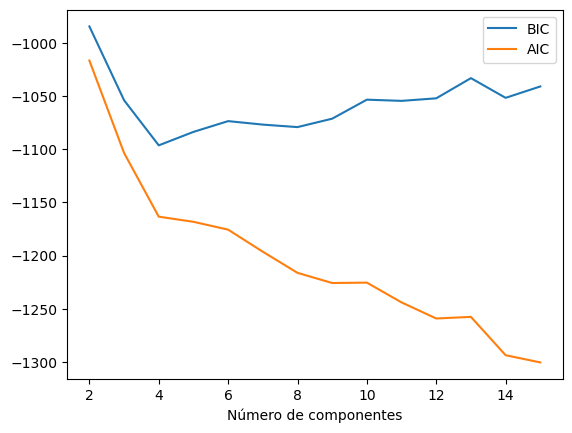

In [18]:
n_components = np.arange(2, 16)
models = [GaussianMixture(n, covariance_type='full', random_state=3).fit(X)
          for n in n_components]

plt.plot(n_components, [m.bic(X) for m in models], label='BIC')
plt.plot(n_components, [m.aic(X) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('Número de componentes')

In [19]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cov_types = ['tied', 'spherical', 'diag', 'full']
n_components_range = [4]

results = []

for cov_type in cov_types:
    for n in n_components_range:
        scores = []
        for train_idx, test_idx in kf.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            
            gmm = GaussianMixture(
                n_components=n,
                covariance_type=cov_type,
                random_state=123
            )
            gmm.fit(X_train)
            scores.append(gmm.score(X_test))  # log-likelihood promedio por muestra
        
        results.append({
            'n_components': n,
            'cov_type': cov_type,
            'cv_score': np.mean(scores)
        })

results_df = pd.DataFrame(results)

In [20]:
results_df.sort_values(by='cv_score', ascending=False)

,n_components,cov_type,cv_score
3,4,full,4.096372
0,4,tied,3.761972
2,4,diag,3.735865
1,4,spherical,3.699452


In [21]:
MMG_BM = GaussianMixture(n_components=4, covariance_type='full',random_state=123)
labels = MMG_BM.fit(X).predict(X)
df['cluster']=labels

Para abordar el ejercicio se siguió el procedimiento:

1. Se toma como estructura de covarianza de referencia *full* ya que es la estructura con mayor flexibilidad y será usada únicamente para la estimación del número de componentes.
2. Posterior a esto se itera desde 2 hasta 15 componentes encontrando algunos hallazgos importantes:
    - Aunque la gráfica de AIC siga bajando constantemente, no se usará como criterio principal de elección del número de componentes dado que se está mostrando un sobreajuste en los datos
    - El número de **componentes = 4** es el ejegido según el grádico BIC para el modelo trabajado.
3. Posterior a la determinación del número de componentes, se utiliza un método Kfold de validación cruzada para iterar sobre las distintas estructuras de covarianza, la que dé el mejor score, encontrando que sigue siendo la estructura de covarianza **full** la más indicada para el conjunto de datos.
4. Finalmente, se corre el modelo según los hiperparametros encontrados como los óptimos: 4 componentes, full estructura de covarianza

#### 3.1. Visualización de los resultados

Visualice las densidades estimadas por el  mejor modelo estimado en la sección anterior usando un mapa de calor interactivo, discuta los resultados.

In [24]:
df.head()

,Restaurante,Dirección,Descripción,Latitud,Longitud,Descripcion_hamburguesa,cluster
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.668833,-74.116828,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",0
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.698395,-74.036585,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",2
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.686401,-74.060144,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",2
3,FRENCHEESE,Calle 51 #22-55,"<p>Presentamos «La French Master», inspirada e...",4.639514,-74.073545,"<p>Presentamos «La French Master», inspirada e...",2
4,FRENCHEESE,Calle 80 #14-41,"<p>Presentamos «La French Master», inspirada e...",4.666147,-74.056758,"<p>Presentamos «La French Master», inspirada e...",2


In [25]:
map_mmg = folium.Map(location = [center_lat, center_lon], zoom_start = 11)

colour = ['red',
    'orange',
    'green',
    'purple',
    ]

def colorCall(val):
  val = int(val)
  return colour[val]

#capa clusters de teatros
for lat, lon, c in zip(df['Latitud'], df['Longitud'], df['cluster']):
    folium.CircleMarker(
        [lat, lon],
        radius=8,
        fill_color = colorCall(c),
        fill=True,
        color=colorCall(c),
        fill_opacity=0.7
        ).add_to(map_mmg)
    


#Display el mapa
map_mmg

Se crea mapa interactivo con los clusters determinando los siguientes hallazgos:

1. El cluster de color rojo, quedó establecido para todos los restaurantes/sucursales en la zona sur-occidente de la ciudad.
2. El cluster de color verde, quedó establecido para todos los restaurantes/sucursales en la zona centro-oriente de la ciudad.
3. El cluster de color naranja, quedó establecido para todos los restaurantes/sucursales en la zona norte de la ciudad.
4. El cluster de color morado, quedó establecido para todos los restaurantes/sucursales en la zona de la sábana de la ciudad.
5. Se pueden observar dos puntos "frontera" para los cluster rojo y verde en los cuales, a pesar de ser restaurantes/sucursales que están ubicados en una misma cuadra, quedaron en clusters diferentes.

### 4. Comparación con KDE

Estime ahora las densidades usando KDE bivariado de la librería `statsmodels` con el anchos de banda dado por `cv_ml`. Muestre los resultados usando un mapa interactivo. Compare los resultados obtenidos por el "mejor" modelo encontrado via MMG. 

In [28]:
# Utilice este espacio para escribir el código.
X = df[['Longitud', 'Latitud']].to_numpy()

kde_cv = sm.nonparametric.KDEMultivariate(data=X, var_type='cc', bw='cv_ml')

x = np.linspace(X[:,0].min() - 0.05, X[:,0].max() + 0.05, 200)  
y = np.linspace(X[:,1].min() - 0.05, X[:,1].max() +0.05, 200) 
xx, yy = np.meshgrid(x, y)
grid = np.column_stack((xx.flatten(), yy.flatten()))

dens_cv = kde_cv.pdf(data_predict=grid).reshape(xx.shape)

C:\Users\danie\anaconda3\Lib\site-packages\statsmodels\nonparametric\kernel_density.py:158: RuntimeWarning: invalid value encountered in log
  L += func(f_i)


In [29]:
dens_norm = (dens_cv - dens_cv.min()) / (dens_cv.max() - dens_cv.min())
heat_data = []
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        heat_data.append([yy[i, j], xx[i, j], dens_norm[i, j]])

map_kde = folium.Map(location=[df['Latitud'].mean(), df['Longitud'].mean()], zoom_start=11)

heat_data = [
    [yy[i, j], xx[i, j], dens_norm[i, j]]
    for i in range(xx.shape[0])
    for j in range(xx.shape[1])
    if dens_norm[i, j] > 0.1
]

HeatMap(heat_data, radius=10, blur=15, max_zoom=13).add_to(map_kde)

In [30]:
map_kde

Como se puede observar en el mapa interactivo, la probablidad de encontrar un restaurante participante en la competencia de Burguer Master, está altamente concentrada en la zona centro oriental de la ciudad, con algunos puntos marcados hacía la sabana, zona sur oriental y zona sur occidente. Estos resultados están altamente relacionados con los clusters encontrados con el mejor modelo de mezclas gaussianas.

De igual forma, se puede observar que las densidades obtenidas a partir del modelo KDE bivariado, tienen una relación con los clusters generados, ya que las zonas de alta densidad podrían solaparse con los clusters, para ilustrarlo se solaparán en un sólo gráfico los clusters y las densidades. 

In [32]:
HeatMap(heat_data, radius=10, blur=15, max_zoom=15).add_to(map_mmg)
map_mmg

Como se puede observar, las densidades están altamente relacionadas con los clusters y nos podría dar a entender incluso, que un número de 3 clusters tambnién se hubiese podido utilizar en el modelo de mezclas gaussianas.

Alguna de las diferencias encontradas podría ser precisamente esa, que el modelo de KDD bivariado parece agrupar los cluster verde y naranja creados con el modelo de mezclas gaussianas que si los considera como puntos pertenecientes a grupos diferentes.

Ambos modelos tienen un desempeño similar aunque cada uno tenga un objetivo diferente en donde en el modelo de mezclas gaussianas buscamos agrupar los datos en clusters o la probabilidad de que un punto pertenezca a un cluster, mientras que en el modelo KDD bivariado lo que estamos encontrando es la probabilidad de que un punto aparezca en una densidad.